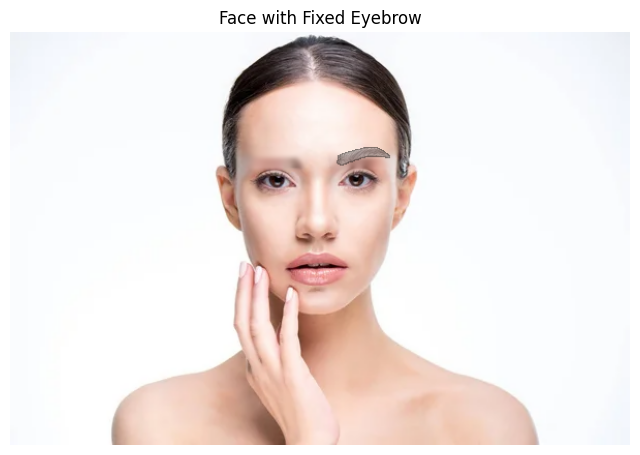

In [20]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

# โหลดภาพใบหน้า
face_path = "C:/Users/Chits/Documents/pensook/Github/Website_DEEPBROW/API/Backend/add_eyebrow/expected_output.png"
face = cv2.imread(face_path, cv2.IMREAD_UNCHANGED)

# โหลดภาพคิ้ว PNG (ต้องมี Transparency)
eyebrow_path = "C:/Users/Chits/Documents/pensook/Github/Website_DEEPBROW/API/Backend/add_eyebrow/style/eyesbrow-1-rmbg.png"
eyebrow = cv2.imread(eyebrow_path, cv2.IMREAD_UNCHANGED)

# ตรวจสอบว่าไฟล์โหลดสำเร็จหรือไม่
if face is None or eyebrow is None:
    print("❌ Error: ไม่สามารถโหลดภาพ")
    exit()

# แปลงภาพเป็น RGB
face_rgb = cv2.cvtColor(face, cv2.COLOR_BGRA2RGB)

# โหลด Mediapipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, min_detection_confidence=0.01) as face_mesh:
    results = face_mesh.process(face_rgb)

# ตรวจสอบว่าพบใบหน้าหรือไม่
if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        ih, iw, _ = face.shape

        # หาตำแหน่งของจุดเริ่มต้นของคิ้ว (จุด 285)
        start_x = int(face_landmarks.landmark[336].x * iw)  # ตำแหน่ง x ของคิ้ว
        start_y = int(face_landmarks.landmark[336].y * ih)  # ตำแหน่ง y ของคิ้ว

        # **ลดขนาดคิ้วอย่างมีคุณภาพ (ใช้ INTER_AREA)**
        scale_factor = 0.25
        eyebrow_width = int(eyebrow.shape[1] * scale_factor)
        eyebrow_height = int(eyebrow.shape[0] * scale_factor)

        # คำนวณตำแหน่งวางคิ้ว
        left_x_min = start_x
        left_x_max = min(start_x + eyebrow_width, iw)
        left_y_min = max(start_y - eyebrow_height // 2, 0)
        left_y_max = min(left_y_min + eyebrow_height, ih)

        # **ลดขนาดคิ้วแบบคุณภาพสูง**
        eyebrow_resized = cv2.resize(eyebrow, (left_x_max - left_x_min, left_y_max - left_y_min), interpolation=cv2.INTER_AREA)

        # **ปรับ Alpha ให้คิ้วดูเนียนขึ้น**
        eyebrow_resized[:, :, 3] = cv2.GaussianBlur(eyebrow_resized[:, :, 3], (3, 3), 2)

        # **ใช้ Alpha Blending ให้ดูเนียนขึ้น**
        for c in range(3):  # วางเฉพาะช่องสี BGR
            face[left_y_min:left_y_max, left_x_min:left_x_max, c] = np.where(
                eyebrow_resized[:, :, 3] > 20,  # ใช้ Alpha Channel เป็นเงื่อนไข
                cv2.addWeighted(face[left_y_min:left_y_max, left_x_min:left_x_max, c], 0.5, eyebrow_resized[:, :, c], 0.5, 0),  # ใช้การผสมสี
                face[left_y_min:left_y_max, left_x_min:left_x_max, c]  # ใช้ค่าสีของใบหน้า
            )

# บันทึกภาพใบหน้าที่มีคิ้วซ้ายที่วางตรงจุด 285
output_path = "C:/Users/Chits/Documents/pensook/Github/Website_DEEPBROW/API/Backend/add_eyebrow.png"
cv2.imwrite(output_path, face)

# แสดงผลลัพธ์
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Face with Fixed Eyebrow")
plt.show()





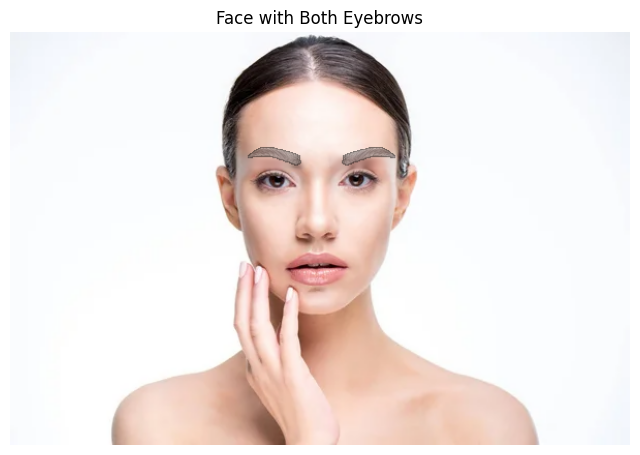

In [25]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

# โหลดภาพใบหน้า
face_path = "C:/Users/Chits/Documents/pensook/Github/Website_DEEPBROW/API/Backend/add_eyebrow/expected_output.png"
face = cv2.imread(face_path, cv2.IMREAD_UNCHANGED)

# โหลดภาพคิ้ว PNG (ต้องมี Transparency)
eyebrow_path = "C:/Users/Chits/Documents/pensook/Github/Website_DEEPBROW/API/Backend/add_eyebrow/style/eyesbrow-1-rmbg.png"
eyebrow = cv2.imread(eyebrow_path, cv2.IMREAD_UNCHANGED)

# ตรวจสอบว่าไฟล์โหลดสำเร็จหรือไม่
if face is None or eyebrow is None:
    print("❌ Error: ไม่สามารถโหลดภาพ")
    exit()

# แปลงภาพเป็น RGB
face_rgb = cv2.cvtColor(face, cv2.COLOR_BGRA2RGB)

# โหลด Mediapipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, min_detection_confidence=0.01) as face_mesh:
    results = face_mesh.process(face_rgb)

# ตรวจสอบว่าพบใบหน้าหรือไม่
if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        ih, iw, _ = face.shape

        # กำหนดตำแหน่งของคิ้วซ้าย (จุด 55) และคิ้วขวา (จุด 285)
        left_brow_x = int(face_landmarks.landmark[107].x * iw) + 5  # ขยับแกน x -5
        left_brow_y = int(face_landmarks.landmark[107].y * ih)
        right_brow_x = int(face_landmarks.landmark[336].x * iw) - 5
        right_brow_y = int(face_landmarks.landmark[336].y * ih)

        # **ลดขนาดคิ้วอย่างมีคุณภาพ (ใช้ INTER_AREA)**
        scale_factor = 0.25
        eyebrow_width = int(eyebrow.shape[1] * scale_factor)
        eyebrow_height = int(eyebrow.shape[0] * scale_factor)

        # สร้างภาพสะท้อนของคิ้วสำหรับคิ้วซ้าย
        left_eyebrow = cv2.flip(eyebrow, 1)

        # **ลดขนาดคิ้วแบบคุณภาพสูง**
        right_eyebrow_resized = cv2.resize(eyebrow, (eyebrow_width, eyebrow_height), interpolation=cv2.INTER_AREA)
        left_eyebrow_resized = cv2.resize(left_eyebrow, (eyebrow_width, eyebrow_height), interpolation=cv2.INTER_AREA)

        # **ใช้ Gaussian Blur ปรับ Alpha ให้ดูเนียนขึ้น**
        right_eyebrow_resized[:, :, 3] = cv2.GaussianBlur(right_eyebrow_resized[:, :, 3], (3, 3), 2)
        left_eyebrow_resized[:, :, 3] = cv2.GaussianBlur(left_eyebrow_resized[:, :, 3], (3, 3), 2)

        # คำนวณตำแหน่งวางคิ้วขวา
        right_x_min = right_brow_x
        right_x_max = min(right_brow_x + eyebrow_width, iw)
        right_y_min = max(right_brow_y - eyebrow_height // 2, 0)
        right_y_max = min(right_y_min + eyebrow_height, ih)

        # คำนวณตำแหน่งวางคิ้วซ้าย
        left_x_min = left_brow_x - eyebrow_width
        left_x_max = left_brow_x
        left_y_min = max(left_brow_y - eyebrow_height // 2, 0)
        left_y_max = min(left_y_min + eyebrow_height, ih)

        # **ใช้ Alpha Blending ให้ดูเนียนขึ้น**
        for c in range(3):  # วางเฉพาะช่องสี BGR
            face[right_y_min:right_y_max, right_x_min:right_x_max, c] = np.where(
                right_eyebrow_resized[:, :, 3] > 20,
                cv2.addWeighted(face[right_y_min:right_y_max, right_x_min:right_x_max, c], 0.5, right_eyebrow_resized[:, :, c], 0.5, 0),
                face[right_y_min:right_y_max, right_x_min:right_x_max, c]
            )
            face[left_y_min:left_y_max, left_x_min:left_x_max, c] = np.where(
                left_eyebrow_resized[:, :, 3] > 20,
                cv2.addWeighted(face[left_y_min:left_y_max, left_x_min:left_x_max, c], 0.5, left_eyebrow_resized[:, :, c], 0.5, 0),
                face[left_y_min:left_y_max, left_x_min:left_x_max, c]
            )

# บันทึกภาพใบหน้าที่มีคิ้วทั้งสองข้าง
output_path = "C:/Users/Chits/Documents/pensook/Github/Website_DEEPBROW/API/Backend/add_eyebrow.png"
cv2.imwrite(output_path, face)

# แสดงผลลัพธ์
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Face with Both Eyebrows")
plt.show()
